In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Generate a simple dataset (linear regression problem)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = 2 * X + 1 + np.random.randn(100, 1) * 2 # y = 2x + 1 + noise

In [4]:
# 2. Define a simple neural network (single neuron, linear activation for simplicity)
# We'll manually implement forward and backward pass

# Initialize weights and bias (deliberately large to exacerbate the problem)
w = np.random.randn(1, 1) * 5 # Initial weight
b = np.random.randn(1, 1) * 5 # Initial bias

learning_rate = 0.5 # Deliberately high learning rate
n_epochs = 50 # Number of training epochs

gradient_magnitudes = [] # To store L2 norm of gradients
losses = [] # To store Mean Squared Error

print(f"Initial weight: {w[0][0]:.4f}, Initial bias: {b[0][0]:.4f}\n")

for epoch in range(n_epochs):
    # Forward pass
    y_pred = X @ w + b

    # Calculate loss (Mean Squared Error)
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)

    # Backward pass (calculate gradients)
    # dL/dy_pred = 2 * (y_pred - y) / N (where N is number of samples)
    # dL/dw = dL/dy_pred * dy_pred/dw = dL/dy_pred * X
    # dL/db = dL/dy_pred * dy_pred/db = dL/dy_pred * 1

    d_loss_d_y_pred = 2 * (y_pred - y) / len(X)
    grad_w = X.T @ d_loss_d_y_pred
    grad_b = np.sum(d_loss_d_y_pred, axis=0)

    # Store gradient magnitude (L2 norm)
    gradient_magnitude = np.sqrt(np.sum(grad_w**2) + np.sum(grad_b**2))
    gradient_magnitudes.append(gradient_magnitude)

    # Update weights and bias
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss:.4f}, Gradient Magnitude: {gradient_magnitude:.4f}, Weight: {w[0][0]:.4f}, Bias: {b[0][0]:.4f}")


Initial weight: 1.2272, Initial bias: 3.1745

Epoch 1/50, Loss: 10.3432, Gradient Magnitude: 28.3385, Weight: 15.3165, Bias: 4.6776
Epoch 6/50, Loss: 11517608229382468.0000, Gradient Magnitude: 1268053867.4624, Weight: -609117814.7531, Bias: -90886840.6691
Epoch 11/50, Loss: 23101719544873921594594514960384.0000, Gradient Magnitude: 56790894025746704.0000, Weight: 27279870566580292.0000, Bias: 4070446171300686.5000
Epoch 16/50, Loss: 46336829253188088601878302367424811562661052416.0000, Gradient Magnitude: 2543429523777079381852160.0000, Weight: -1221752701628566946709504.0000, Bias: -182298467820174768603136.0000
Epoch 21/50, Loss: 92941209032880444742876486866625377171308018158533942766993408.0000, Gradient Magnitude: 113909700725755481696437469708288.0000, Weight: 54717256091579001049715742605312.0000, Bias: 8164395245881356954666853728256.0000
Epoch 26/50, Loss: 186419063965177723444118162433725033273779966364636895880018107008988678717440.0000, Gradient Magnitude: 5101544901532102

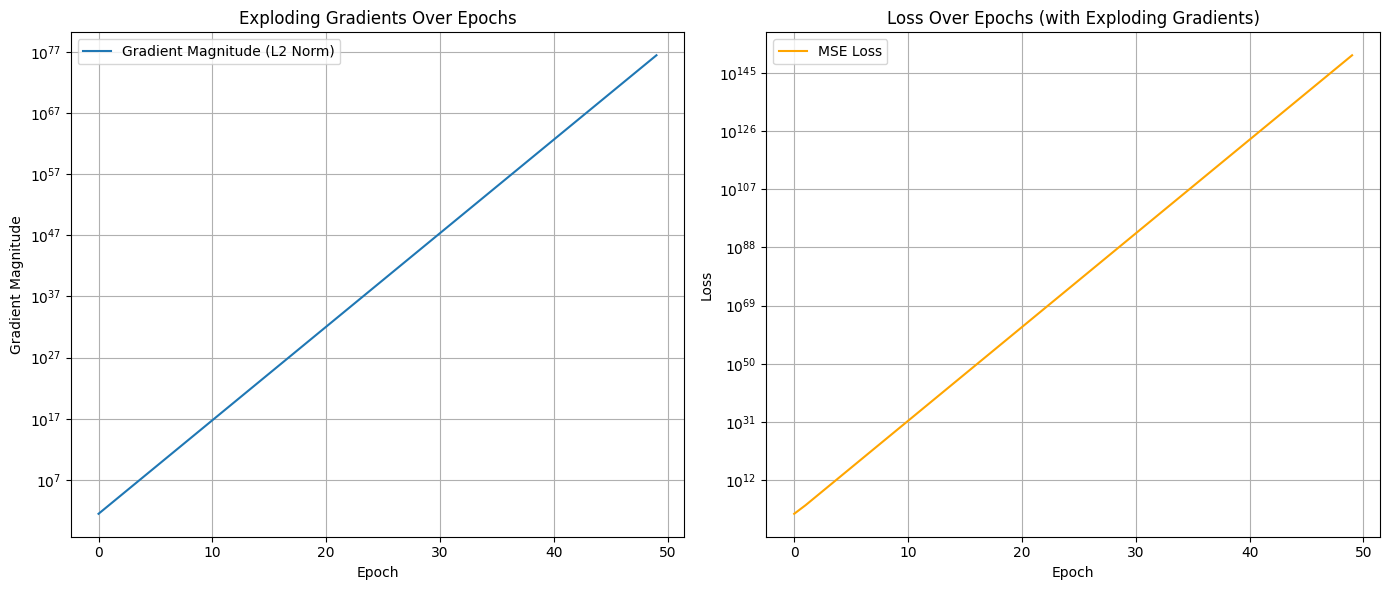

In [5]:
# 3. Plot the gradient magnitudes and loss
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(n_epochs), gradient_magnitudes, label='Gradient Magnitude (L2 Norm)')
plt.title('Exploding Gradients Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Use log scale to better visualize explosion
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(n_epochs), losses, label='MSE Loss', color='orange')
plt.title('Loss Over Epochs (with Exploding Gradients)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log') # Use log scale for loss as well
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Observations

In the plots above, you should observe the following:

1.  **Exploding Gradients**: The 'Gradient Magnitude' plot shows a sharp, often exponential, increase in the gradient values early in the training. This indicates that the gradients are growing out of control.
2.  **Diverging Loss**: The 'MSE Loss' plot will also show a rapid increase in loss (or NaN/infinity values) as the gradients explode, demonstrating that the model is failing to learn and is diverging.

This behavior is a clear sign of the Exploding Gradient Problem. To mitigate this, techniques like **gradient clipping**, using smaller **learning rates**, or **batch normalization** are often employed.